In [2]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2
from qiskit import transpile

In [3]:
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_blais = ['#33658A','#86BBD8']

In [4]:
token = '2712985633675e074d63da9266dba7714d932b8e447f0f4632ca0965701237c6fb67854d65b3457cf7087e056cda6859748c77bd7721251cdaf17e9a1e30e6cc'
provider = qiskit_ibm_provider.IBMProvider(token)

In [5]:
instance = 'ibm-q/open/main'

device = 'sherbrooke'
backend_name = 'ibm_'+device # get_backend_name(device)
backend = provider.get_backend(backend_name, instance=instance)

In [6]:
n_qubits = backend.configuration().n_qubits
qubits = np.arange(n_qubits)

scan_backend(token, provider, device)
colors_gradient = get_color_gradient('#0000FF', '#FF0000', n_qubits)

(no-q) Device: sherbrooke
q = 0: T1 = 307us, T2 = 224us
q = 1: T1 = 308us, T2 = 312us
q = 2: T1 = 205us, T2 = 158us
q = 3: T1 = 441us, T2 = 221us
q = 4: T1 = 377us, T2 = 415us
q = 5: T1 = 260us, T2 = 298us
q = 6: T1 = 283us, T2 = 427us
q = 7: T1 = 286us, T2 = 271us
q = 8: T1 = 423us, T2 = 301us
q = 9: T1 = 287us, T2 = 69us
q = 10: T1 = 216us, T2 = 180us
q = 11: T1 = 470us, T2 = 98us
q = 12: T1 = 403us, T2 = 277us
q = 13: T1 = 350us, T2 = 166us
q = 14: T1 = 258us, T2 = 156us
q = 15: T1 = 403us, T2 = 306us
q = 16: T1 = 337us, T2 = 165us
q = 17: T1 = 234us, T2 = 78us
q = 18: T1 = 243us, T2 = 57us
q = 19: T1 = 461us, T2 = 132us
q = 20: T1 = 504us, T2 = 89us
q = 21: T1 = 442us, T2 = 25us
q = 22: T1 = 132us, T2 = 168us
q = 23: T1 = 147us, T2 = 204us
q = 24: T1 = 273us, T2 = 182us
q = 25: T1 = 275us, T2 = 484us
q = 26: T1 = 313us, T2 = 210us
q = 27: T1 = 311us, T2 = 122us
q = 28: T1 = 224us, T2 = 63us
q = 29: T1 = 399us, T2 = 191us
q = 30: T1 = 374us, T2 = 256us
q = 31: T1 = 234us, T2 = 32us


In [3]:
n_qubits = backend.configuration().n_qubits
qubits = np.arange(n_qubits)

scan_backend(token, provider, device)
colors_gradient = get_color_gradient('#0000FF', '#FF0000', n_qubits)

(no-q) Device: hanoi
q = 0: T1 = 176us, T2 = 246us
q = 1: T1 = 43us, T2 = 57us
q = 2: T1 = 157us, T2 = 152us
q = 3: T1 = 103us, T2 = 30us
q = 4: T1 = 87us, T2 = 16us
q = 5: T1 = 143us, T2 = 148us
q = 6: T1 = 169us, T2 = 231us
q = 7: T1 = 128us, T2 = 69us
q = 8: T1 = 178us, T2 = 216us
q = 9: T1 = 110us, T2 = 118us
q = 10: T1 = 122us, T2 = 183us
q = 11: T1 = 161us, T2 = 238us
q = 12: T1 = 234us, T2 = 227us
q = 13: T1 = 91us, T2 = 137us
q = 14: T1 = 185us, T2 = 26us
q = 15: T1 = 165us, T2 = 40us
q = 16: T1 = 138us, T2 = 267us
q = 17: T1 = 132us, T2 = 70us
q = 18: T1 = 142us, T2 = 145us
q = 19: T1 = 15us, T2 = 23us
q = 20: T1 = 114us, T2 = 55us
q = 21: T1 = 92us, T2 = 31us
q = 22: T1 = 127us, T2 = 132us
q = 23: T1 = 169us, T2 = 115us
q = 24: T1 = 216us, T2 = 41us
q = 25: T1 = 187us, T2 = 93us
q = 26: T1 = 118us, T2 = 38us


In [7]:
import qutip as qt
from qutip import sigmaz, sigmax, sigmay, identity, tensor
from qutip.solver import Options

X = sigmax()
Y = sigmay()
Z = sigmaz()
sX = X.sqrtm()
sY = Y.sqrtm()
sXdg = sX.dag()
sYdg = sY.dag()
I = identity(2)
S = qt.qip.operations.s_gate()
Sdg = S.dag()

psi_0 = qt.states.basis(2,0)
rho_0 = qt.ket2dm(psi_0)
psi_1 = qt.states.basis(2,1)
rho_1 = qt.ket2dm(psi_1)
psi_p = X.sqrtm() * psi_0
rho_p = qt.ket2dm(psi_p)
psi_m = X.sqrtm().dag() * psi_0
rho_m = qt.ket2dm(psi_m)

a_op = 0.5*(sigmax()+1j*sigmay())
adg_op = 0.5*(sigmax()-1j*sigmay())
adag_op = 0.5*(sigmax()-1j*sigmay())
aI = tensor(a_op,I)
Ia = tensor(I,a_op)

In [8]:
nc = noise_characterization(backend, 0, m_FTTPS=4)
FTTPS_circs = nc.generate_FTTPS_circuits()

K = nc.num_FTTPS
kk = np.arange(K)
dt = backend.properties().__dict__['_gates']['id'][(0,)]['gate_length'][0]*1e6
T = 2*K*dt
print("dt = %.5f"%dt)

FTTPS num: 16
dt = 0.05689


In [9]:
options = Options(store_final_state=True, rtol=1e-10, nsteps=50000)

# $\nu>0,\gamma=\lambda=0$

In [13]:
beta = 0./dt
epsilon = 0.0
omega = np.pi*(1+epsilon)/dt

gamma = 0.00/dt
lmbda = 0.00/dt
nu = 0.002/dt

L_envs = [np.sqrt(gamma)*a_op,np.sqrt(lmbda/2)*Z]
L_ctrl = [np.sqrt(nu/2)*X]

In [14]:
ps = []
for k,circ in enumerate(FTTPS_circs):
    print("[%d]"%k, end=' ')
    rho = rho_p
    for moment in circ[1:-2]:
        H = beta*Z/2 if moment.operations[0].gate==cirq.I else beta*Z/2 + omega*X/2
        L_ops = L_envs if moment.operations[0].gate==cirq.I else L_envs+L_ctrl
        rho = qt.mesolve(H, rho, [0,dt], L_ops, options=options).final_state
    rho = sXdg*rho*sX
    ps += [np.trace(rho*rho_0).real]

[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 

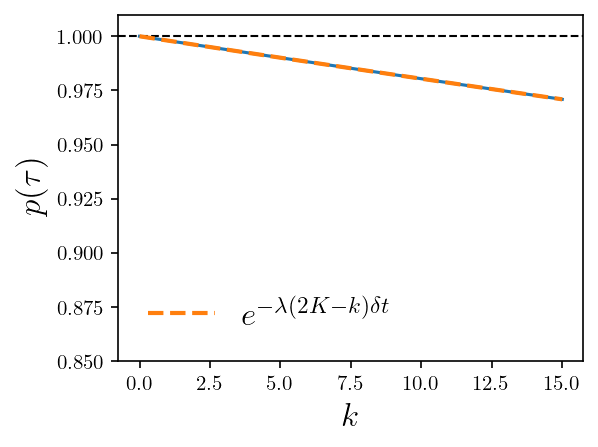

In [15]:
plt.figure(dpi=150, figsize=(4,3))
plt.plot(kk,ps)
plt.axhline(1,color='k',ls='--',lw=1)
plt.plot(kk,(1+np.exp(-kk*nu*dt*2))/2,lw=2, ls='--', label='$e^{-\lambda(2K-k) \delta t}$')
plt.ylim(0.85,1.01)
plt.ylabel(r"$p(\tau)$", size=16)
plt.xlabel(r"$k$", size=16)
plt.legend(frameon=False, fontsize=16)
plt.show()

# $\lambda>0,\gamma=\nu=0$

In [16]:
beta = 0./dt
epsilon = 0.0
omega = np.pi*(1+epsilon)/dt

gamma = 0.00/dt
lmbda = 0.002/dt
nu = 0.00/dt

L_envs = [np.sqrt(gamma/2)*a_op,np.sqrt(lmbda/2)*Z]
L_ctrl = [np.sqrt(nu/2)*X]

In [17]:
ps = []
for k,circ in enumerate(FTTPS_circs):
    print("[%d]"%k, end=' ')
    rho = rho_p
    for moment in circ[1:-2]:
        H = beta*Z/2 if moment.operations[0].gate==cirq.I else beta*Z/2 + omega*X/2
        L_ops = L_envs if moment.operations[0].gate==cirq.I else L_envs+L_ctrl
        rho = qt.mesolve(H, rho, [0,dt], L_ops, options=options).final_state
    rho = sXdg*rho*sX
    ps += [np.trace(rho*rho_0).real]

[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 

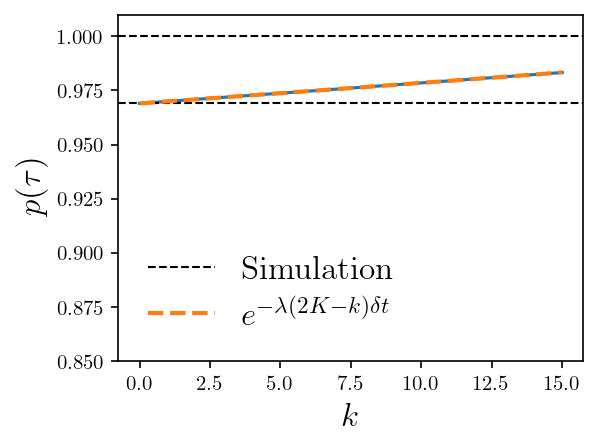

In [18]:
plt.figure(dpi=150, figsize=(4,3))
plt.plot(kk,ps)
plt.axhline(1,color='k',ls='--',lw=1,label='Simulation')
plt.axhline((1+np.exp(-(gamma/2+lmbda)*T))/2,color='k',ls='--',lw=1)
plt.plot(kk,(1+np.exp(-lmbda*(2*K-kk)*dt))/2, lw=2, ls='--', label='$e^{-\lambda(2K-k) \delta t}$')
plt.ylim(0.85,1.01)
plt.ylabel(r"$p(\tau)$", size=16)
plt.xlabel(r"$k$", size=16)
plt.legend(frameon=False, fontsize=16)
plt.show()

# $\gamma>0,\lambda=\nu=0$

In [19]:
beta = 0./dt
epsilon = 0.0
omega = np.pi*(1+epsilon)/dt

gamma = 0.005/dt
q = 0.1
lmbda = 0.00/dt
nu = 0.00/dt

L_envs = [np.sqrt(q*gamma)*a_op,np.sqrt((1-q)*gamma)*adg_op,np.sqrt(lmbda/2)*Z]
L_ctrl = [np.sqrt(nu/2)*X]

In [20]:
ps = []
for k,circ in enumerate(FTTPS_circs):
    print("[%d]"%k, end=' ')
    rho = rho_p
    for moment in circ[1:-2]:
        H = beta*Z/2 if moment.operations[0].gate==cirq.I else beta*Z/2 + omega*X/2
        L_ops = L_envs if moment.operations[0].gate==cirq.I else L_envs+L_ctrl
        rho = qt.mesolve(H, rho, [0,dt], L_ops, options=options).final_state
    rho = sXdg*rho*sX
    ps += [np.trace(rho*rho_0).real]

[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 

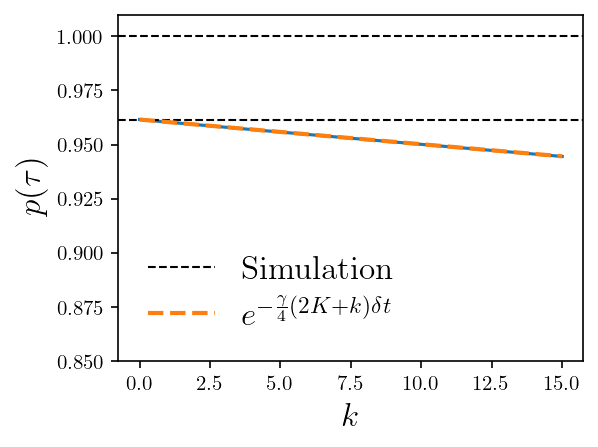

In [21]:
plt.figure(dpi=150, figsize=(4,3))
plt.plot(kk,ps)
plt.axhline(1,color='k',ls='--',lw=1,label='Simulation')
plt.axhline((1+np.exp(-(gamma/2+lmbda)*T))/2,color='k',ls='--',lw=1)
plt.plot(kk,(1+np.exp(-gamma/2*(2*K+kk)*dt))/2, lw=2, ls='--', label=r'$e^{-\frac{\gamma}{4}(2K+k) \delta t}$')
plt.ylim(0.85,1.01)
plt.ylabel(r"$p(\tau)$", size=16)
plt.xlabel(r"$k$", size=16)
plt.legend(frameon=False, fontsize=16)
plt.show()

# $\nu,\gamma,\lambda>0$

In [237]:
beta = 0./dt
epsilon = 0.0
omega = np.pi*(1+epsilon)/dt

ps = {}
for i in range(10):
    gamma = 0.01*np.random.rand(1)[0]/dt
    lmbda = 0.01*np.random.rand(1)[0]/dt
    nu = 0.01*np.random.rand(1)[0]/dt
    
    L_envs = [np.sqrt(gamma)*a_op,np.sqrt(lmbda/2)*Z]
    L_ctrl = [np.sqrt(nu/2)*X]
    
    ps[(gamma,lmbda,nu)] = []
    for k,circ in enumerate(FTTPS_circs):
        print("[%d]"%k, end=' ')
        rho = rho_p
        for moment in circ[1:-2]:
            H = beta*Z/2 if moment.operations[0].gate==cirq.I else beta*Z/2 + omega*X/2
            L_ops = L_envs if moment.operations[0].gate==cirq.I else L_envs+L_ctrl
            rho = qt.mesolve(H, rho, [0,dt], L_ops, options=options).final_state
        rho = sXdg*rho*sX
        ps[(gamma,lmbda,nu)] += [np.trace(rho*rho_0).real]
    print("")

[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] 


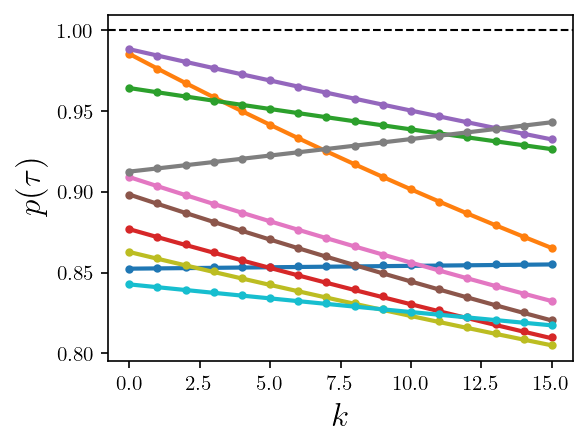

In [240]:
plt.figure(dpi=150, figsize=(4,3))
plt.axhline(1,color='k',ls='--',lw=1)

for i,((gamma,lmbda,nu),ps_i) in enumerate(ps.items()):
    plt.plot(kk,ps_i, marker='.', ls='', color=colors[i])
    plt.plot(kk,(1+np.exp(-(gamma/2*(2*K+kk)+lmbda*(2*K-kk)+kk*nu*2)*dt))/2, lw=2, ls='-', color=colors[i])
    
plt.ylabel(r"$p(\tau)$", size=16)
plt.xlabel(r"$k$", size=16)
# plt.ylim(0.85,1.01)
# plt.legend(frameon=False, fontsize=16)
plt.show()

# Choose Noise Parameters

In [10]:
weak_noise_params = {'beta': 0.002/dt,
                    'epsilon': 0.001,
                    'gamma': 0.001/dt,
                    'lambda': 0.001/dt,
                    'nu':    0.001/dt}
strong_noise_params = {'beta': 0.02/dt,
                    'epsilon':   0.02,
                    'gamma': 0.01/dt,
                    'lambda': 0.02/dt,
                    'nu':    0.005/dt}
param_labels = ['beta','epsilon','gamma','lambda','nu']

# All together now

In [11]:
nc = noise_characterization(backend, 0, m_FTTPS=6)
FTTPS_circs = nc.generate_FTTPS_circuits()

K = nc.num_FTTPS
kk = np.arange(K)
T = 2*K*dt

FTTPS num: 64


In [12]:
ps = {}
for i,label in enumerate(param_labels):
    beta, epsilon, gamma, lmbda, nu = weak_noise_params.values()
    if label=='beta':
        beta = strong_noise_params['beta']
    elif label=='epsilon':
        epsilon = strong_noise_params['epsilon']
    elif label=='gamma':
        gamma = strong_noise_params['gamma']
    elif label=='lambda':
        lmbda = strong_noise_params['lambda']
    elif label=='nu':
        nu = strong_noise_params['nu']
    
    L_envs = [np.sqrt(gamma)*a_op,np.sqrt(lmbda/2)*Z]
    L_ctrl = [np.sqrt(nu/2)*X]
    
    omega = np.pi*(1+epsilon)/dt
    
    ps[(beta,epsilon,gamma,lmbda,nu)] = []
    for k,circ in enumerate(FTTPS_circs):
        print("[%d]"%k, end=' ')
        rho = rho_p
        for moment in circ[1:-2]:
            H = beta*Z/2 if moment.operations[0].gate==cirq.I else beta*Z/2 + omega*X/2
            L_ops = L_envs if moment.operations[0].gate==cirq.I else L_envs+L_ctrl
            rho = qt.mesolve(H, rho, [0,dt], L_ops, options=options).final_state
        rho = sXdg*rho*sX
        ps[(beta,epsilon,gamma,lmbda,nu)] += [np.trace(rho*rho_0).real]
    print("")

[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] [16] [17] [18] [19] [20] [21] [22] [23] [24] [25] [26] [27] [28] [29] [30] [31] [32] [33] [34] [35] [36] [37] [38] [39] [40] [41] [42] [43] [44] [45] [46] [47] [48] [49] [50] [51] [52] [53] [54] [55] [56] [57] [58] [59] [60] [61] [62] [63] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] [16] [17] [18] [19] [20] [21] [22] [23] [24] [25] [26] [27] [28] [29] [30] [31] [32] [33] [34] [35] [36] [37] [38] [39] [40] [41] [42] [43] [44] [45] [46] [47] [48] [49] [50] [51] [52] [53] [54] [55] [56] [57] [58] [59] [60] [61] [62] [63] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [15] [16] [17] [18] [19] [20] [21] [22] [23] [24] [25] [26] [27] [28] [29] [30] [31] [32] [33] [34] [35] [36] [37] [38] [39] [40] [41] [42] [43] [44] [45] [46] [47] [48] [49] [50] [51] [52] [53] [54] [55] [56] [57] [58] [59] [60] [61] [62] [63] 
[0] [1] [2] [3] [4] [5] [6] [7] [8] [9] [10] [11] [12] [13] [14] [1

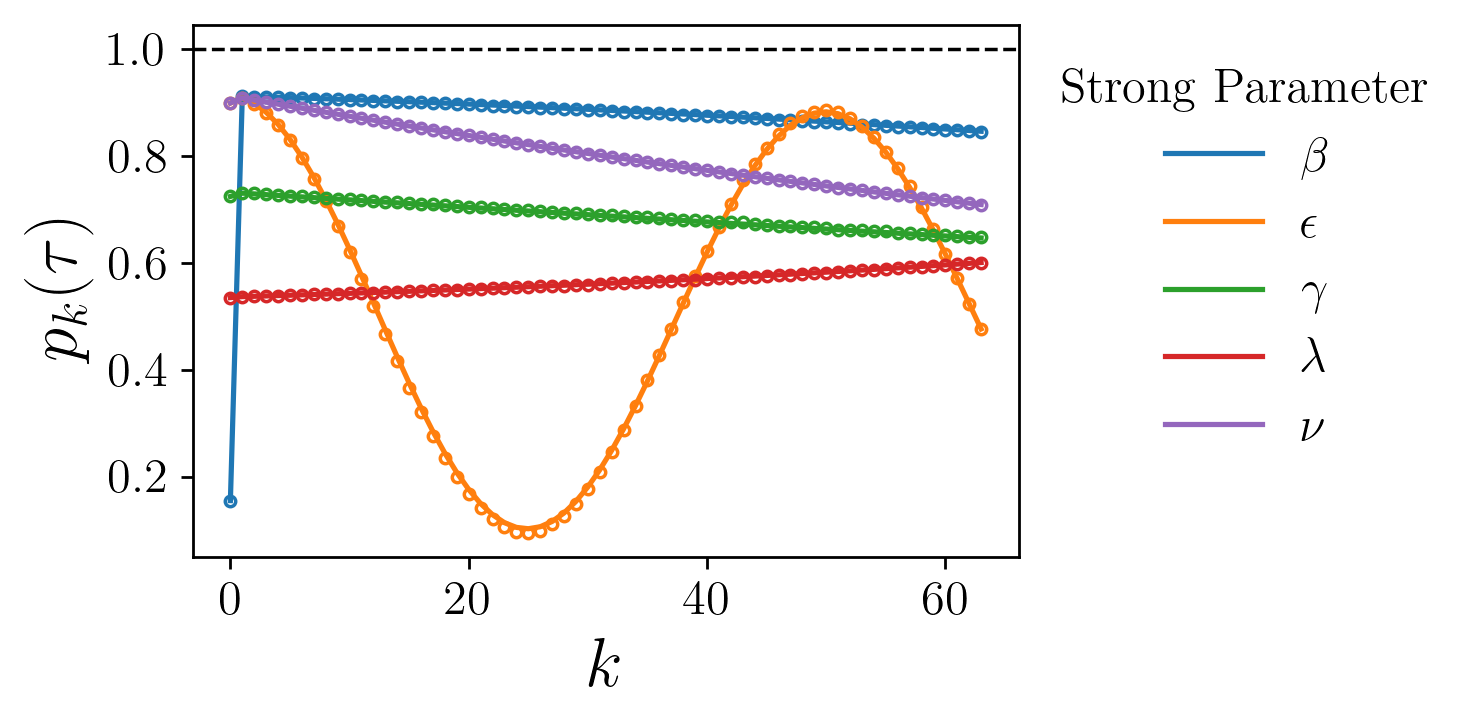

In [13]:
plt.figure(dpi=250, figsize=(6,3))
plt.axhline(1,color='k',ls='--',lw=1)

for i,((beta,epsilon,gamma,lmbda,nu),ps_i) in enumerate(ps.items()):
    plt.plot(kk,ps_i, marker='.', mfc='None', ls='', color=colors[i])
    ps_th = np.concatenate(([(1+np.cos(beta*T)*np.exp(-(gamma/2+lmbda)*T))/2], 
                           (1+np.cos(np.pi*2*epsilon*kk[1:])*np.exp(-(gamma/2*(2*K+kk[1:])+lmbda*(2*K-kk[1:])+kk[1:]*nu*2)*dt))/2))
    plt.plot(kk,ps_th, lw=1.5, ls='-', color=colors[i], label='$\%s$'%param_labels[i])

plt.ylabel(r"$p_k(\tau)$", size=20)
plt.xlabel(r"$k$", size=20)
plt.tick_params(labelsize=14)
plt.legend(frameon=False, fontsize=14, title=r'Strong Parameter', title_fontsize=14, bbox_to_anchor=(1,1) )
plt.tight_layout()
plt.savefig('figures/FTTPS_markovian.pdf')
plt.show()